
Random_state:  51
             1E           2E          2D           3E         3P        3S
14    12.193548     0.000000    0.000000     0.000000   0.000000   0.00000
44     0.000000     0.000000    0.000000     0.000000  14.008065  54.41129
5      1.145161     6.709677    0.000000     0.000000   0.000000   0.00000
30  2190.822581  1420.500000  591.306452  1017.435484   0.000000   0.00000
27     5.170000     8.080000   19.285000     0.054000   3.640000  46.98500
34    41.064516     0.000000   19.451613    31.911290   0.000000   0.00000
60    13.806452     4.854839   42.112903    15.419355   2.758065   0.00000
18     0.000000     9.370968    6.790323    14.693548  19.854839   0.00000
22     0.000000     0.000000   30.258065     0.000000  18.483871   0.00000
32     0.000000     0.000000    5.540323     4.290323   4.411290   0.00000
35     0.000000     9.209677    1.000000    33.927419  69.169355   0.00000

14    1
44    0
5     0
30    1
27    1
34    0
60    0
18    1
22    1
32    1


<Figure size 80000x24000 with 0 Axes>

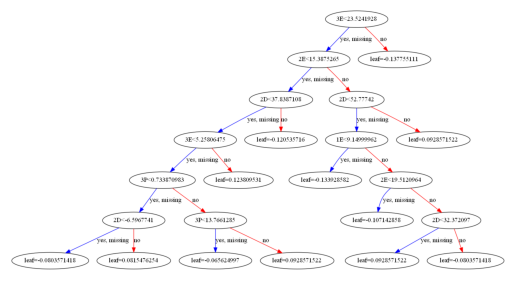

Accuracy: 54.54545454545454 %
------------------------------------------XGBClassifier 1-------------------------------
              precision    recall  f1-score   support

     healing       0.75      0.60      0.67         5
 Not-healing       0.67      0.67      0.67         6

   micro avg       0.70      0.64      0.67        11
   macro avg       0.71      0.63      0.67        11
weighted avg       0.70      0.64      0.67        11
 samples avg       0.64      0.64      0.64        11



C:\Users\natej\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


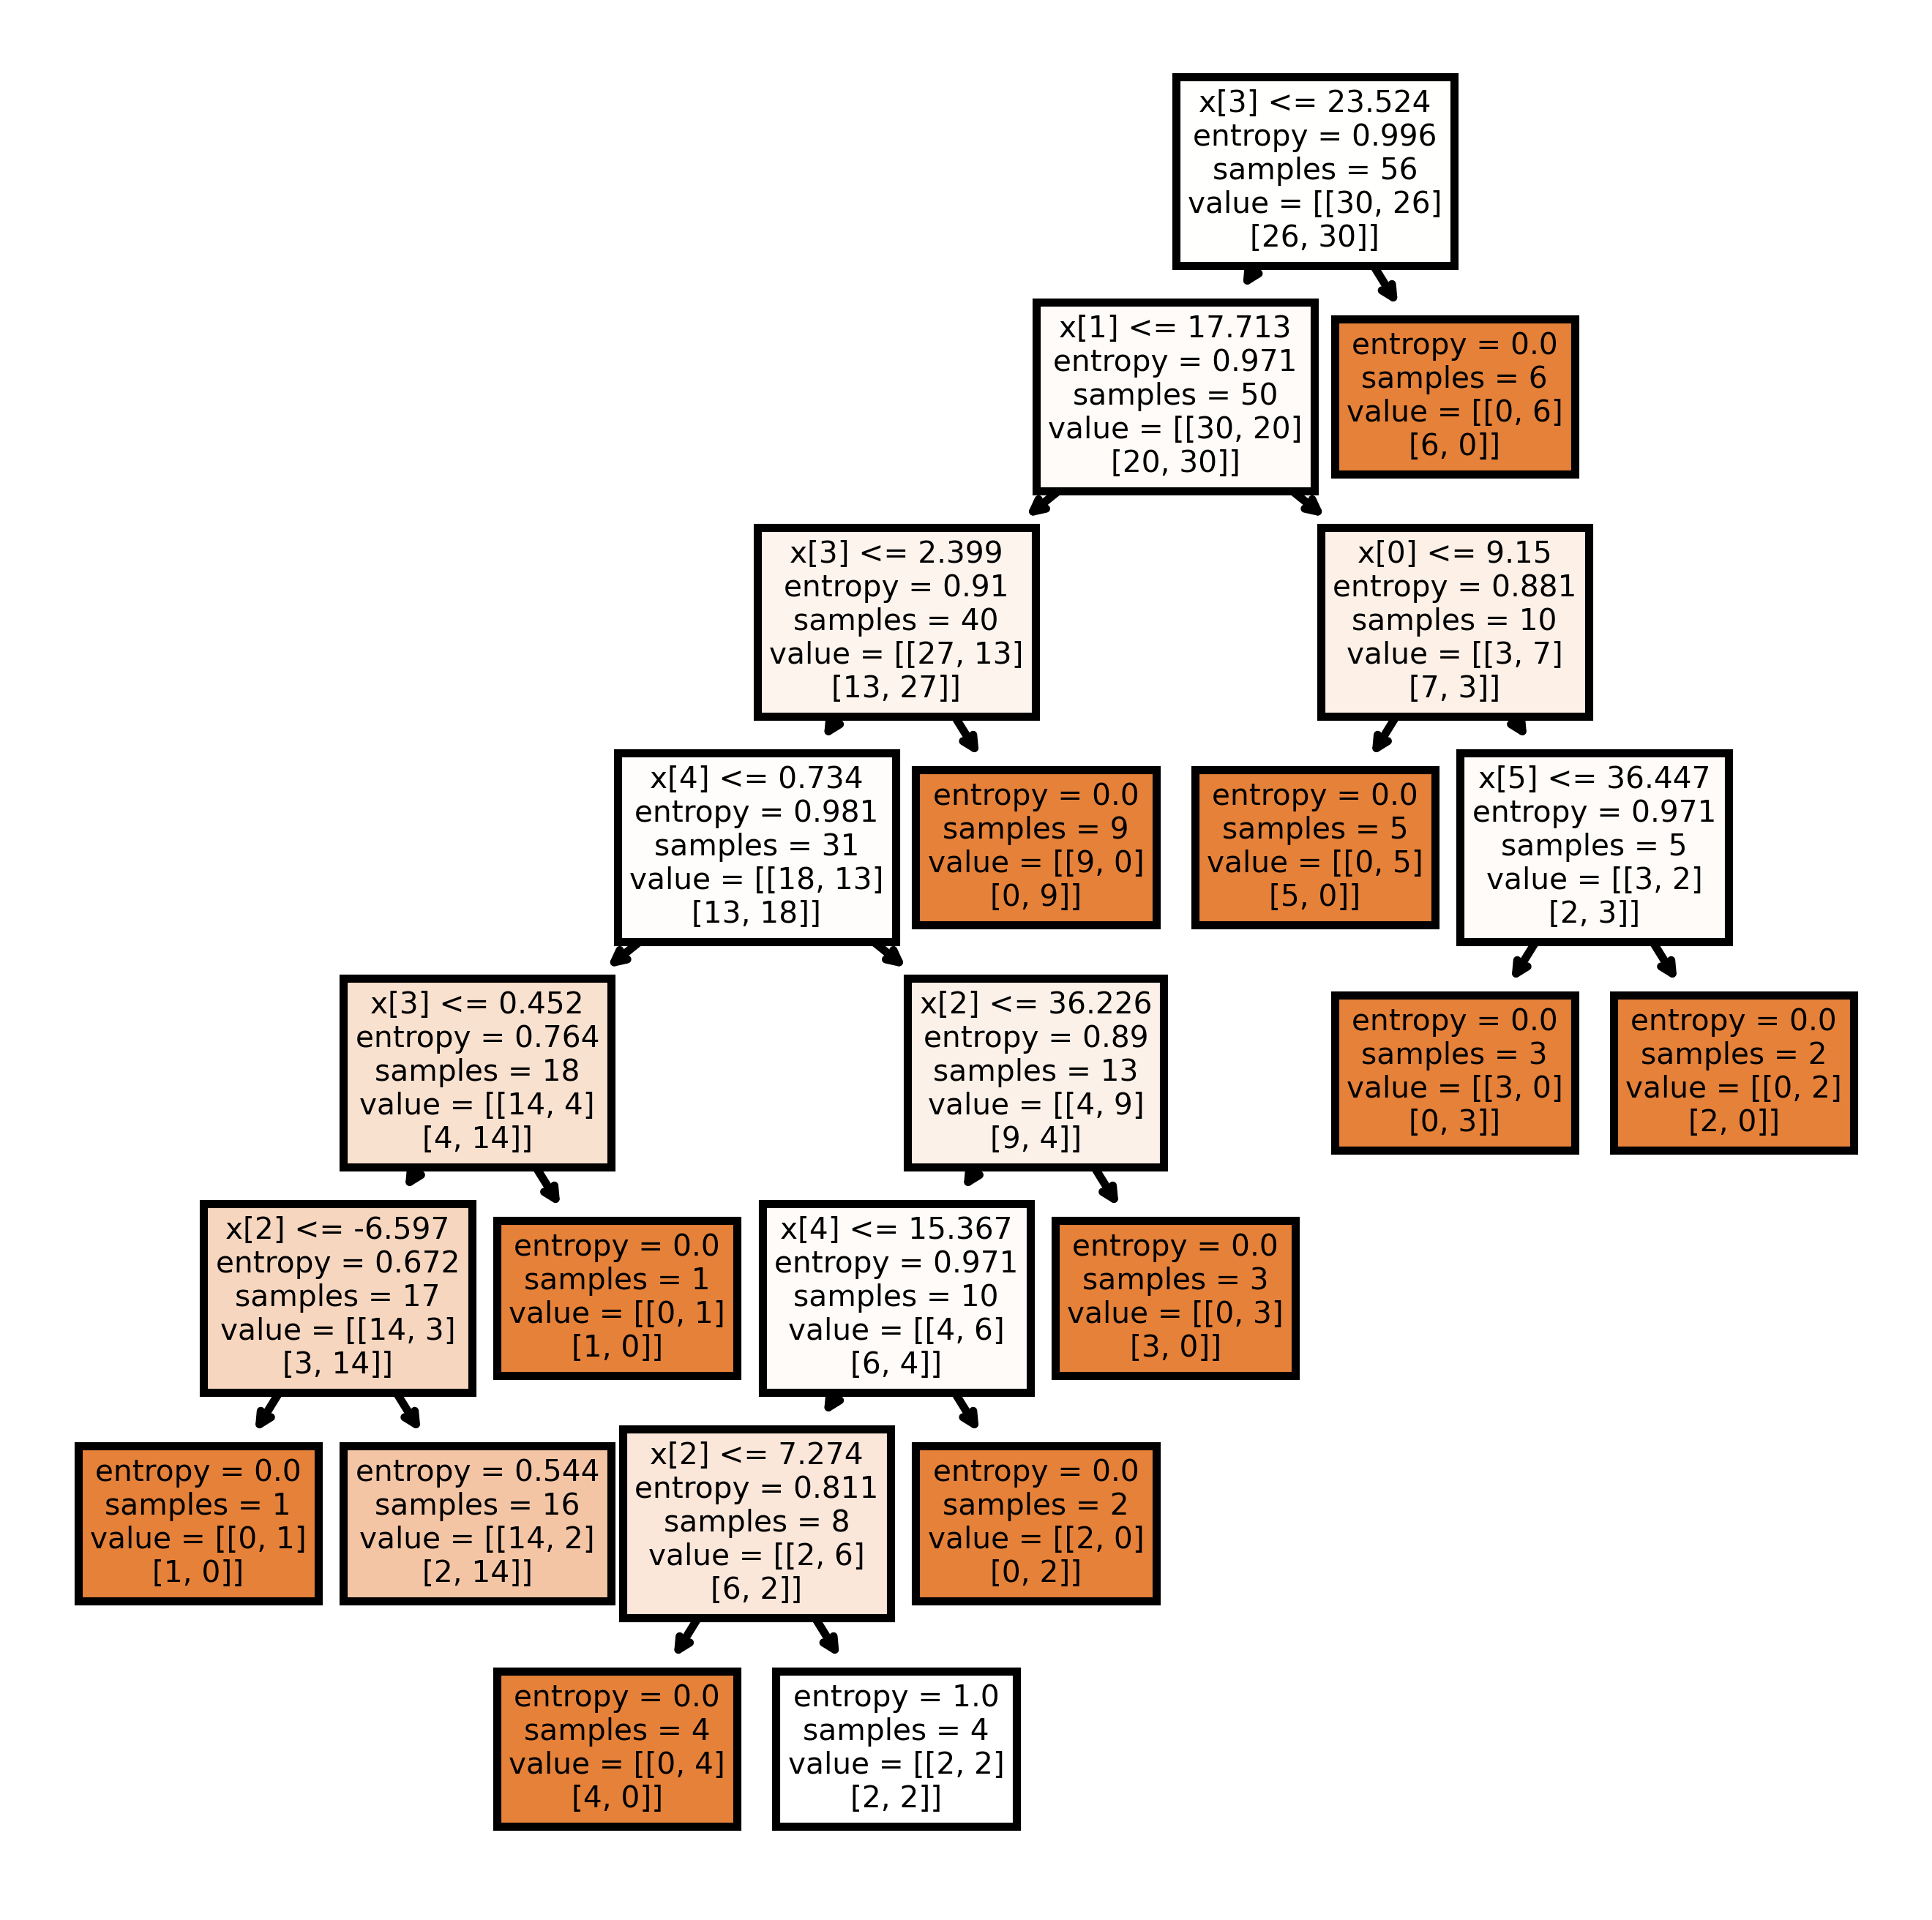

Accuracy: 63.63636363636363 %
------------------------------------------DecisionTreeClassifier 2-------------------------------


C:\Users\natej\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:777: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


              precision    recall  f1-score   support

     healing       0.40      0.40      0.40         5
 Not-healing       0.50      0.50      0.50         6

   micro avg       0.45      0.45      0.45        11
   macro avg       0.45      0.45      0.45        11
weighted avg       0.45      0.45      0.45        11
 samples avg       0.45      0.45      0.45        11



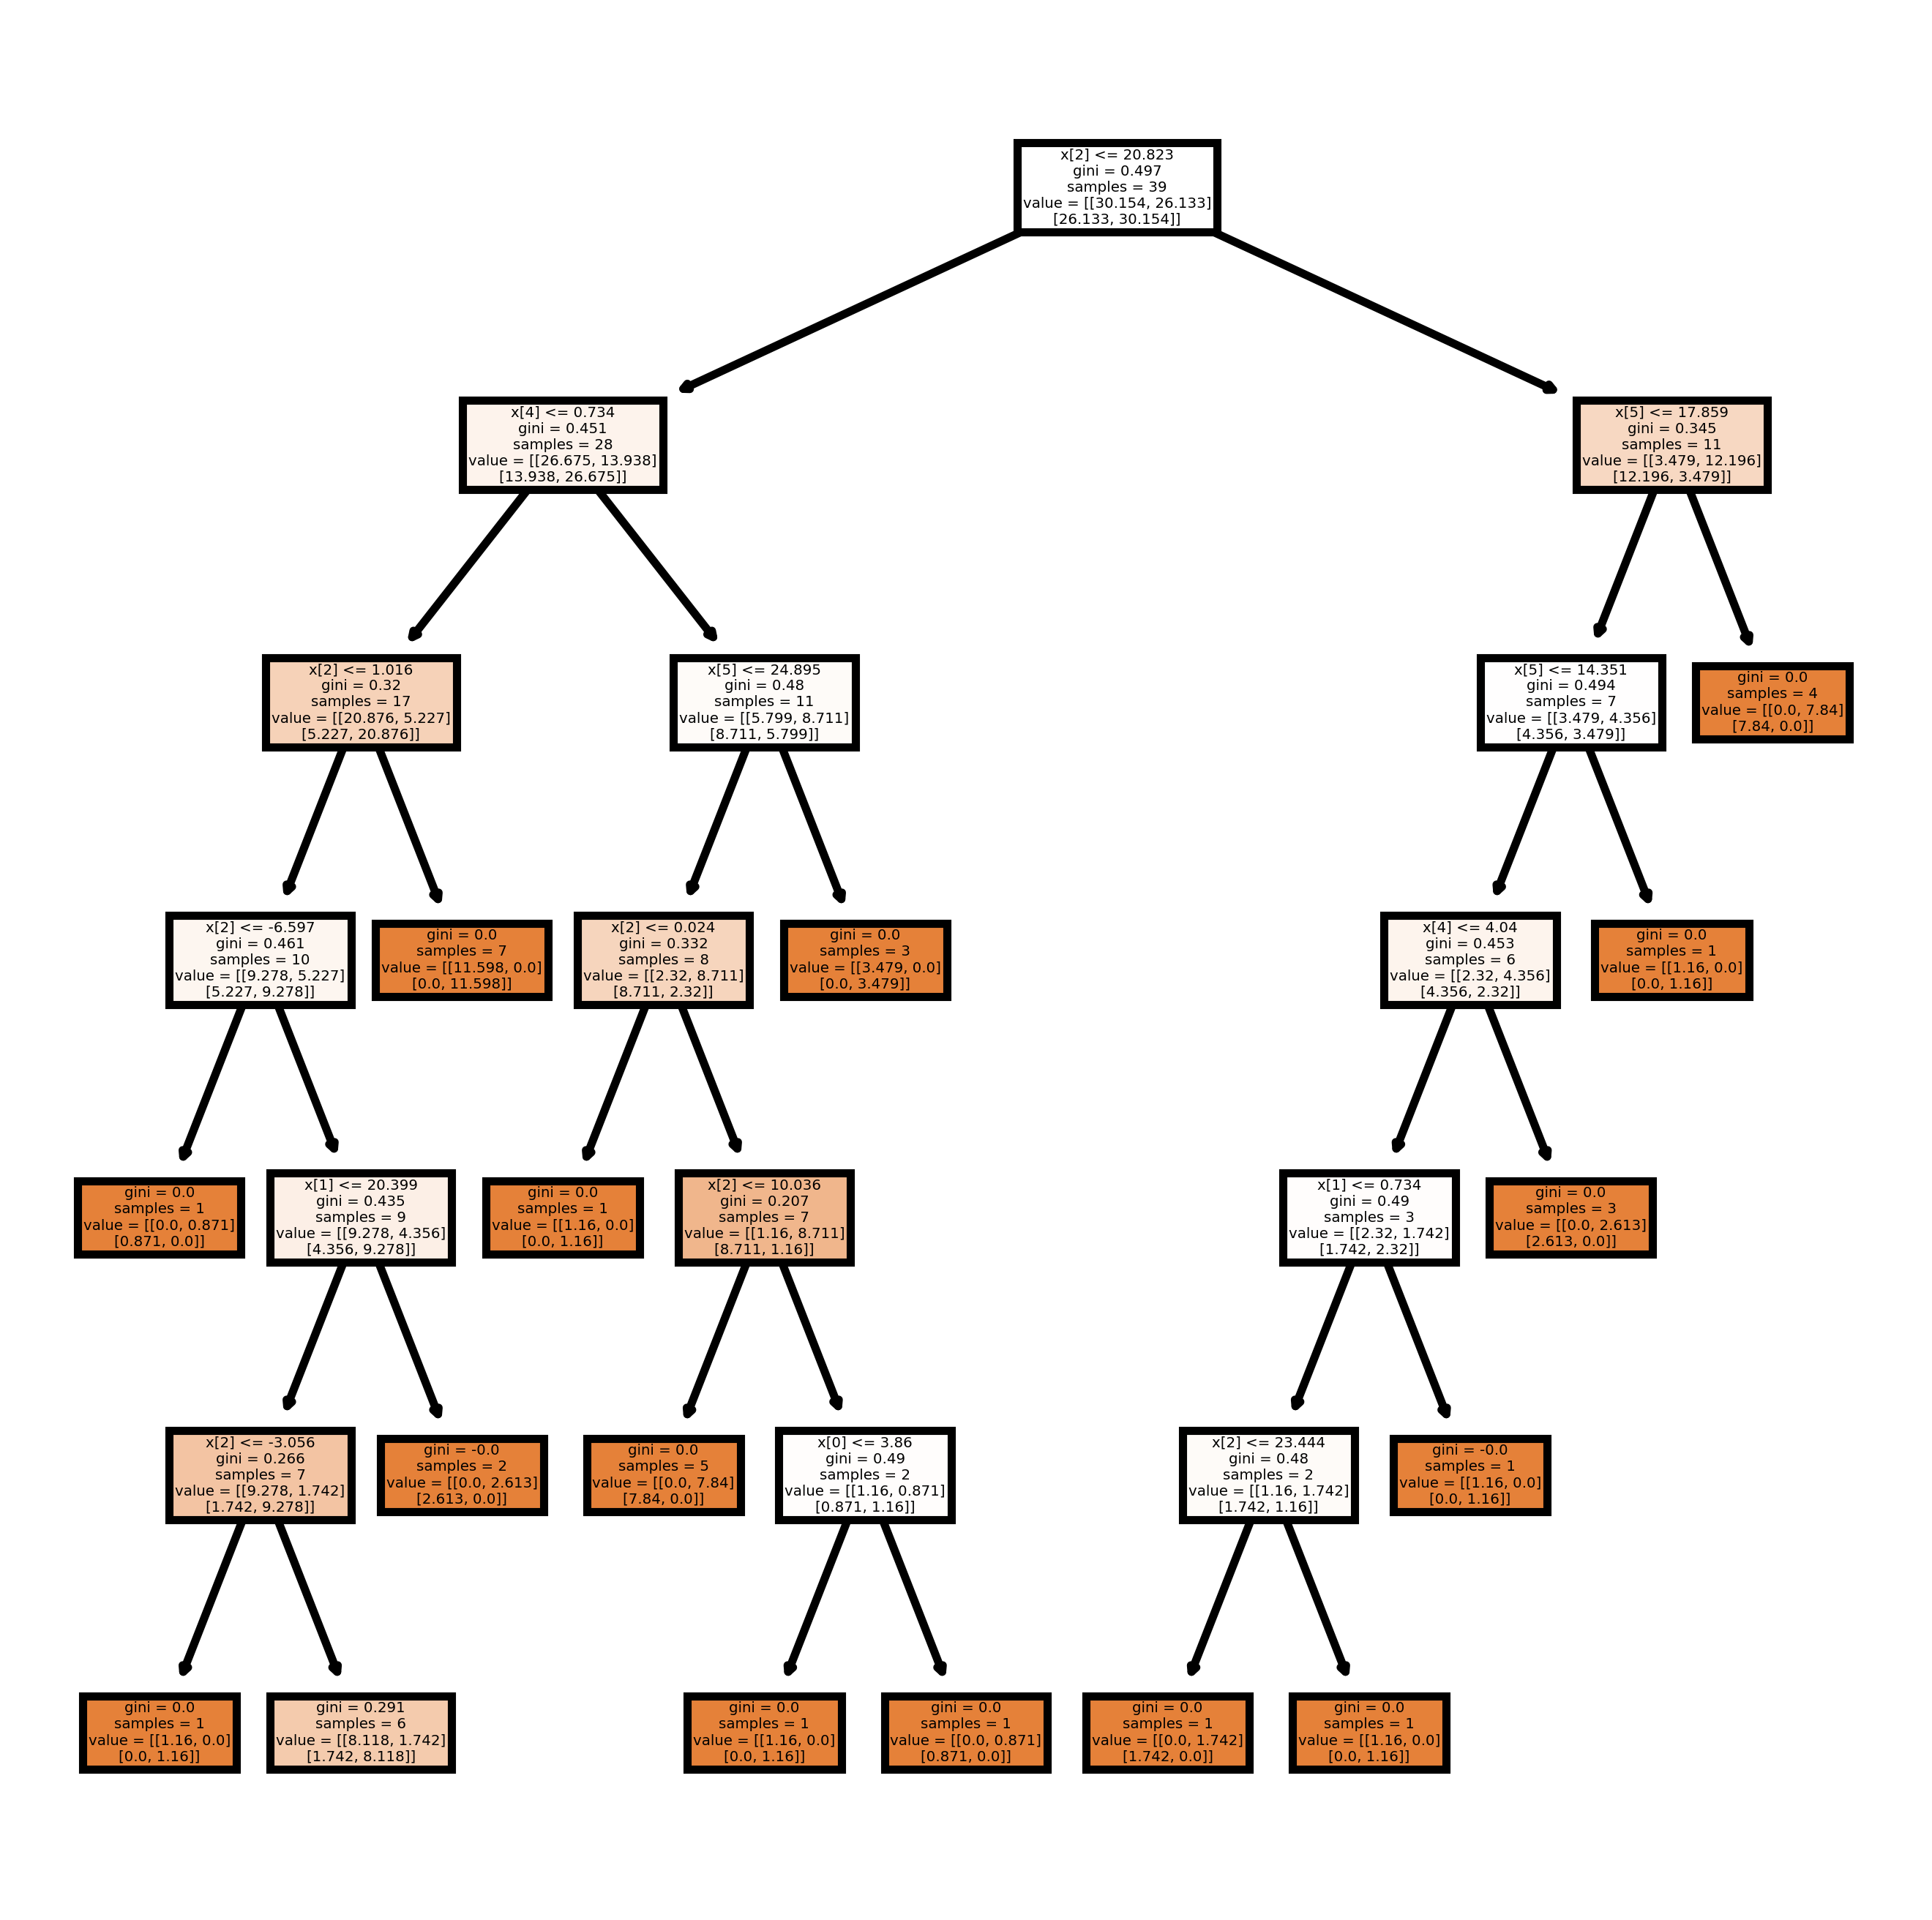

Accuracy: 45.45454545454545 %
------------------------------------------RandomForestClassifier 3-------------------------------


C:\Users\natej\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:777: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


              precision    recall  f1-score   support

     healing       0.75      0.60      0.67         5
 Not-healing       0.71      0.83      0.77         6

    accuracy                           0.73        11
   macro avg       0.73      0.72      0.72        11
weighted avg       0.73      0.73      0.72        11

Accuracy: 72.72727272727273 %
''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
Accuracy: 94.02985074626866 %
              precision    recall  f1-score   support

     healing       0.97      0.90      0.93        31
 Not-healing       0.92      0.97      0.95        36

    accuracy                           0.94        67
   macro avg       0.94      0.94      0.94        67
weighted avg       0.94      0.94      0.94        67

[[0.08425962 0.91574038]
 [0.1152701  0.8847299 ]
 [0.94028947 0.05971053]
 [0.91548956 0.08451045]
 [0.89755048 0.10244952]
 [0.07656075 0.92343925]
 [0.08558159 0.91441841]
 [0.02488435 0.975

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
import random
from tensorflow.keras.utils import to_categorical
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import pickle



Treatment=pd.read_csv("../dissertation/Pro Full_1.csv")

df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]
R_state=random.randrange(1,100)
print("Random_state: ",R_state)
R_state=92
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y,test_size=0.15, random_state=R_state,stratify=df_y)
y_train_clf = to_categorical(y_train)
y_test_clf = to_categorical(y_test)
print(X_test)
print("")
print(y_test)
df_y=to_categorical(df_y)
fullinfo=True
fulltree=True
furtherinfo=False


def class1():
    clf=XGBClassifier(tree_method="exact",
                      objective="reg:squarederror",
    )
    if fullinfo==True:
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
        
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(800, 240))
            plot_tree(clf)
            #plt.savefig('DTC keras', dpi=1200)
            plt.show()
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("------------------------------------------XGBClassifier 1-------------------------------")
        if furtherinfo==True:
            print("''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''")
            y_pred = clf.predict(df_x)
           # accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
            accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
            print("Accuracy:", (accuracy*100),"%")
            print(classification_report(np.asarray(df_y).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
            f, axes = plt.subplots(1, 2, figsize=(15, 10))
            axes = axes.ravel()
            #goal_class=["Healing","non-healing","deterioration"]
            for i in range(2):
                disp = ConfusionMatrixDisplay(confusion_matrix(np.asarray(df_y).argmax(axis=1),
                                                       y_pred),
                                              display_labels=[0, i])
                disp.plot(ax=axes[i], values_format='.4g')
                #disp.ax_.set_title(goal_class[i])
                if i<10:
                    disp.ax_.set_xlabel('')
                if i%5!=0:
                    disp.ax_.set_ylabel('')
                disp.im_.colorbar.remove()

            plt.subplots_adjust(wspace=0.10, hspace=0.1)
            f.colorbar(disp.im_, ax=axes)
            plt.show()
            print("_______________________________________________________________________________________________")
    return clf

def class2():
    clf=DecisionTreeClassifier(max_depth=7,
                               criterion="entropy",
                               ccp_alpha=0.02,
                              # criterion="log_loss",
                              
    )
    if fullinfo==True:
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
            tree.plot_tree(clf, 
               filled = True);
            #f, axes = plt.subplots(1, 2, figsize=(15, 10))
            #axes = axes.ravel()
            plt.show()
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("------------------------------------------DecisionTreeClassifier 2-------------------------------")
        if furtherinfo==True:
            print("''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''")
            y_pred = clf.predict(df_x)
           # accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
            accuracy = accuracy_score(df_y, y_pred)
            print("Accuracy:", (accuracy*100),"%")
            print(classification_report(df_y,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
            f, axes = plt.subplots(1, 2, figsize=(15, 10))
            axes = axes.ravel()
            #goal_class=["Healing","non-healing","deterioration"]
            for i in range(2):
                disp = ConfusionMatrixDisplay(confusion_matrix(np.asarray(df_y).argmax(axis=1),
                                                       y_pred.argmax(axis=1)),
                                              display_labels=[0, i])
                disp.plot(ax=axes[i], values_format='.4g')
                #disp.ax_.set_title(goal_class[i])
                if i<10:
                    disp.ax_.set_xlabel('')
                if i%5!=0:
                    disp.ax_.set_ylabel('')
                disp.im_.colorbar.remove()

            plt.subplots_adjust(wspace=0.10, hspace=0.1)
            f.colorbar(disp.im_, ax=axes)
            plt.show()
            print("_______________________________________________________________________________________________")
    return clf

def class3():
    clf = RandomForestClassifier(max_depth=6,warm_start=True,class_weight="balanced_subsample",n_estimators=500,random_state=9)
    if fullinfo==True:
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
            tree.plot_tree(clf.estimators_[0], 
               filled = True);
            #f, axes = plt.subplots(1, 2, figsize=(15, 10))
            #axes = axes.ravel()
            plt.show()
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("------------------------------------------RandomForestClassifier 3-------------------------------")
        if furtherinfo==True:
            print("''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''")
            y_pred = clf.predict(df_x)
           # accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
            accuracy = accuracy_score(df_y, y_pred)
            print("Accuracy:", (accuracy*100),"%")
            print(classification_report(df_y,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
            f, axes = plt.subplots(1, 2, figsize=(15, 10))
            axes = axes.ravel()
            #goal_class=["Healing","non-healing","deterioration"]
            for i in range(2):
                disp = ConfusionMatrixDisplay(confusion_matrix(np.asarray(df_y).argmax(axis=1),
                                                       y_pred.argmax(axis=1)),
                                              display_labels=[0, i])
                disp.plot(ax=axes[i], values_format='.4g')
                #disp.ax_.set_title(goal_class[i])
                if i<10:
                    disp.ax_.set_xlabel('')
                if i%5!=0:
                    disp.ax_.set_ylabel('')
                disp.im_.colorbar.remove()

            plt.subplots_adjust(wspace=0.10, hspace=0.1)
            f.colorbar(disp.im_, ax=axes)
            plt.show()
            print("_______________________________________________________________________________________________")
    return clf
    

    
def VoteClass():
    clf1=class1()
    clf2=class2()
    clf3=class3()
    sclf = VotingClassifier(estimators=[('clf1', clf1), ('clf2', clf2), ('clf3', clf3)],voting='soft',flatten_transform=False)
    
    sclf.fit(X_train, y_train)
    
    y_pred = sclf.predict(X_test)
    print(classification_report(np.asarray(y_test_clf).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
    accuracy = accuracy_score(np.asarray(y_test_clf).argmax(axis=1), y_pred)
    print("Accuracy:", (accuracy*100),"%")
    
    y_pred = sclf.predict_proba(X_test)
    print("''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''")
    y_pred = sclf.predict(df_x)
    accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
    print("Accuracy:", (accuracy*100),"%")
    print(classification_report(np.asarray(df_y).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    y_pred = sclf.predict_proba(df_x)
    print(y_pred)
    
    
    

VoteClass()